# Plotting API expansion — Phase 3

Advanced numerical and dynamical visualizations with bounded computational work.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import kiwicalc as kw

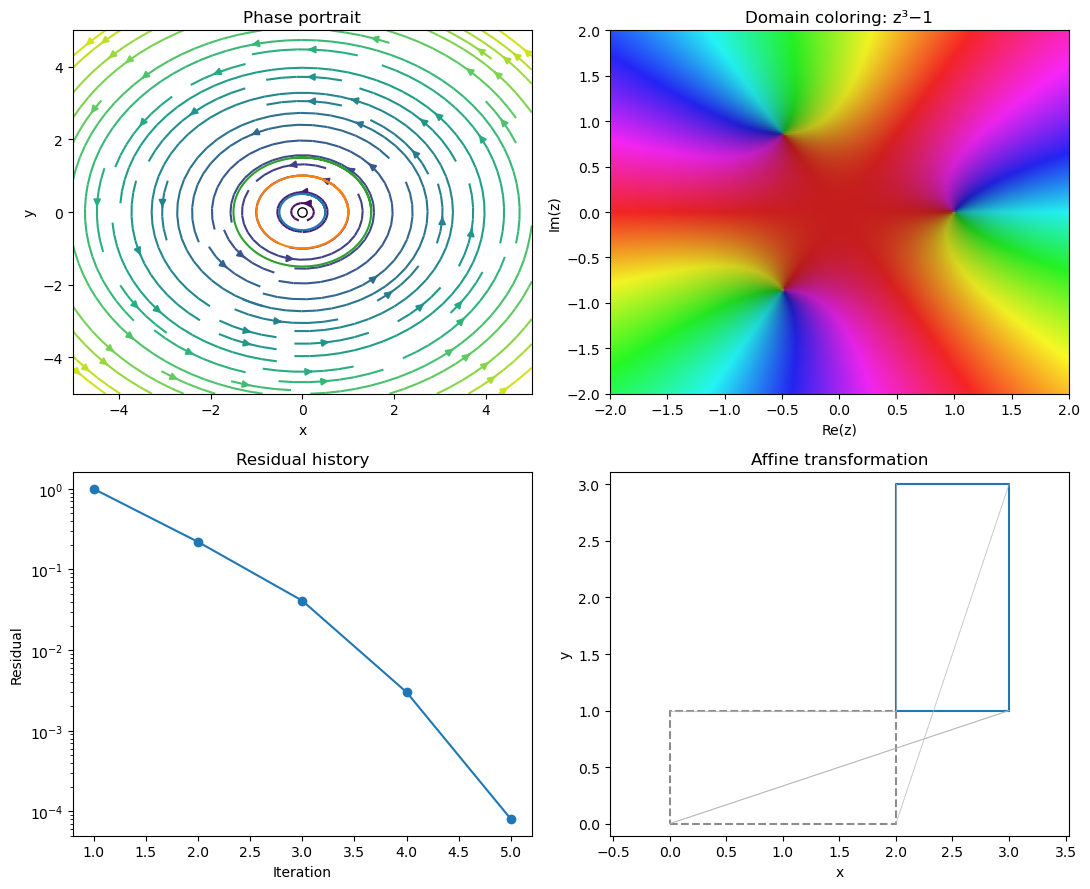

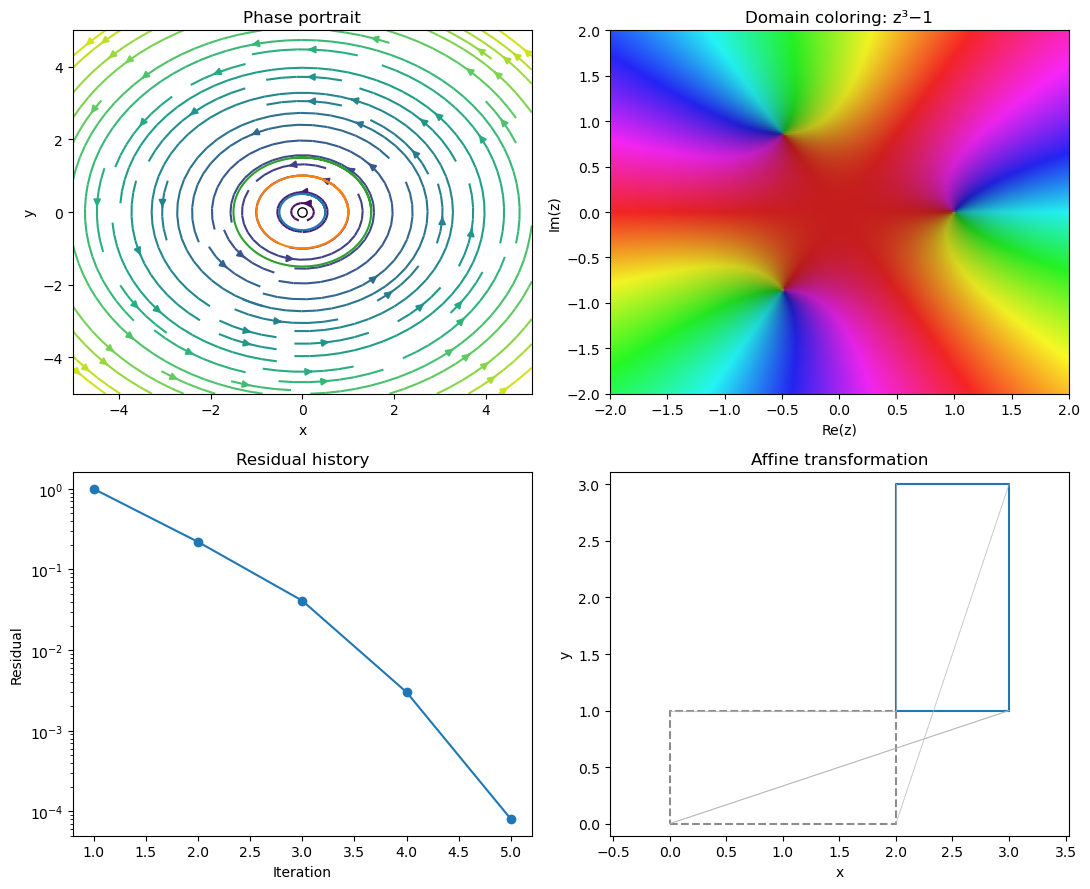

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
portrait = kw.plot_phase_portrait(
    lambda x, y: -y, lambda x, y: x, density=25,
    initial_conditions=[(0.5, 0), (1, 0), (1.5, 0)],
    trajectory_steps=300, t_span=(0, 8), title='Phase portrait',
    fig=fig, ax=axes[0, 0], show=False,
)
complex_image = kw.plot_complex_function(
    lambda z: z**3-1, samples=180, mode='domain',
    title='Domain coloring: z³−1', fig=fig, ax=axes[0, 1], show=False,
)
convergence = kw.plot_convergence(
    [1, 0.22, 0.041, 0.003, 0.00008], title='Residual history',
    fig=fig, ax=axes[1, 0], show=False,
)
transform = kw.plot_transform(
    [(0, 0), (2, 0), (2, 1), (0, 1), (0, 0)],
    [[0, -1, 3], [1, 0, 1], [0, 0, 1]], connectors=5,
    connect=True, title='Affine transformation', fig=fig, ax=axes[1, 1], show=False,
)
fig.tight_layout()
assert len(portrait.trajectories) == 3
assert complex_image.kiwicalc_values.shape == (180, 180)
fig

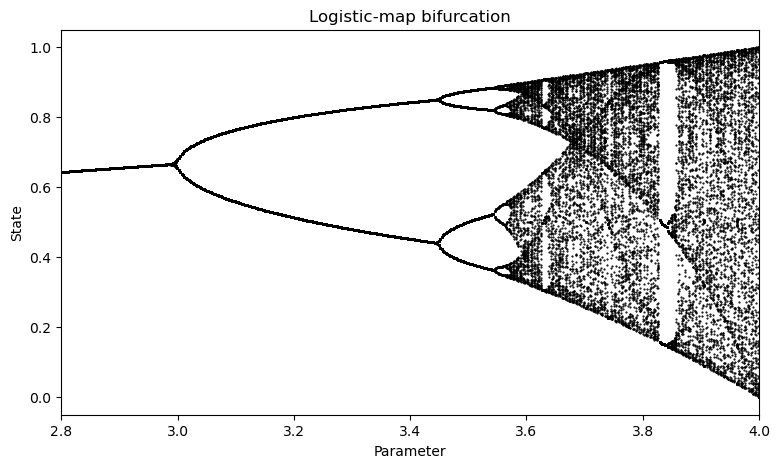

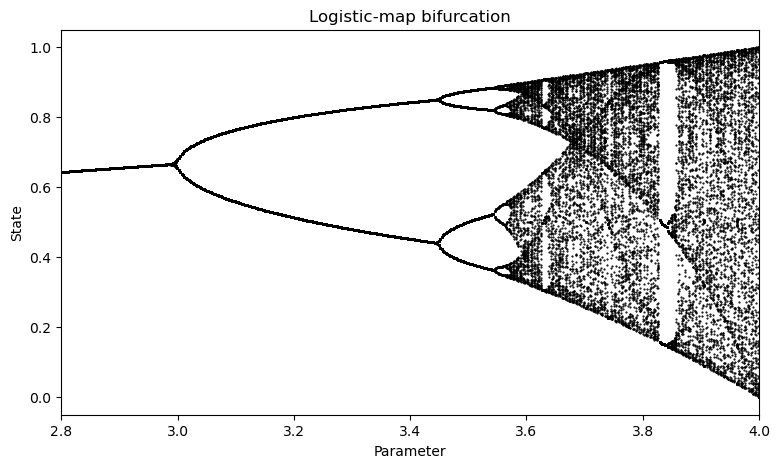

In [3]:
fig2, ax2 = plt.subplots(figsize=(9, 5))
bifurcation = kw.plot_bifurcation(
    lambda state, r: r*state*(1-state), parameter_range=(2.8, 4),
    parameter_samples=500, burn_in=300, keep=80,
    title='Logistic-map bifurcation', fig=fig2, ax=ax2, show=False,
)
assert 0 < len(bifurcation.kiwicalc_states) <= 40_000
fig2